<a href="https://colab.research.google.com/github/Chaminwoo/MLHW4/blob/main/4_202211384_%EC%B0%A8%EB%AF%BC%EC%9A%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2>개인 구글 드라이브와 colab 연동</h2>

In [40]:
from google.colab import drive
drive.mount("/gdrive", force_remount=True)

Mounted at /gdrive


<h2>"SMSSpamCollection" 데이터를 읽고 문장과 정답을 분리하여 각 리스트에 저장</h2>

<pre>
<b>1. 데이터의 형태(SMSSpamCollection)</b>
  라벨(스팸 또는 햄) \t(tab) 문장
  
  위와 같은 형태로 저장되어 있음
  
  예시)
    ham\tGo until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
    spam\tCustomer service annoncement. You have a New Years delivery waiting for you. Please call 07046744435 now to arrange delivery
    ...
  
  따라서 입력 데이터를 읽고 \t을 기준으로 입력 문장을 분리한 후에 문장과 라벨을 각각 x_data, y_data 리스트에 저장
  
<b>2. 최대한 많은 학습을 위해 1000개의 데이터를 사용</b>

<b>3. x_data, y_data 형태</b>
  x_data = [ 문장1, 문장2, 문장3, ... 문장500]
  y_data = [ 문장1의 라벨, 문장2의 라벨, 문장3의 라벨, ... 문장500의 라벨]

<b>4. 최종 학습 모델의 테스트를 위한 데이터셋 추출 (10%)</b>
</pre>

In [41]:
import numpy as np

file_path = "/gdrive/My Drive/ML colab/work3/SMSSpamCollection.dat"

# 파일 읽기
x_data, y_data = [], []
with open(file_path,'r',encoding='utf8') as inFile:
  lines = inFile.readlines()

tmp_lines = lines[:1000]

for line in tmp_lines:
  line = line.strip().split('\t')
  sentence, label = line[1], line[0]
  x_data.append(sentence)
  y_data.append(label)

test_lines = lines[1000:1100]
real_test_x, real_test_y = [], []
for line in test_lines:
    line = line.strip().split('\t')
    sentence, label = line[1], line[0]
    real_test_x.append(sentence)
    real_test_y.append(label)

print("x_data의 개수 : " + str(len(x_data)))
print("y_data의 개수 : " + str(len(y_data)))

print("실전 테스트 데이터 개수:", len(real_test_x))

x_data의 개수 : 1000
y_data의 개수 : 1000
실전 테스트 데이터 개수: 100


<h2>Tokenizer 라이브러리를 사용하여 입력 문장을 index로 치환</h2>

<pre>
<b>1. tokenizer.fit_on_texts(data) 함수를 이용하여 각 단어를 index로 치환하기 위한 딕셔너리 생성</b>
   생성된 딕셔너리는 tokenizer 객체 안에 저장됨
  
  tokenizer.fit_on_texts(data)
  args
    data : 문자열 element를 가지고 있는 리스트
  return
    X
    
  딕셔너리 예시)
    {'to': 1, 'i': 2, 'you': 3, 'a': 4, 'the': 5, 'and': 6, 'for': 7 ... }
    
<b>2. tokenizer.texts_to_sequences(data) 함수를 이용하여 문장 안에 있는 단어들을 index로 치환</b>

  tokenizer.texts_to_sequence(data)
  args
    data : 문자열 element를 가지고 있는 리스트
  return :
    indexing 된 리스트
    
  indexing 예시)
    x_data indexing 하기 전 : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
    x_data indexing 하기 후 : [38, 93, 239, 240, 241, 242, 53, 11, 243, 72, 94, 244, 245, 126, 246, 247, 73, 74, 248, 127]
    y_data indexing 하기 전 : ham
    y_data indexing 하기 후 : 1
</pre>

In [42]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer()

# spam, ham 라벨을 대응하는 index로 치환하기위한 딕셔너리
label2index_dict = {'spam':0, 'ham':1}

# indexing 한 데이터를 넣을 리스트 선언
indexing_x_data, indexing_y_data = [], []

for label in y_data:
  indexing_y_data.append(label2index_dict[label])


# x_data를 사용하여 딕셔너리 생성
tokenizer.fit_on_texts(x_data)
# x_data에 있는 각 문장의 단어들을 대응하는 index로 치환하고 그 결과값을 indexing_x_data에 저장
# 이곳을 채우세요.
indexing_x_data = tokenizer.texts_to_sequences(x_data)

print("x_data indexing 하기 전 : " + str(x_data[0]))
print("x_data indexing 하기 후 : " + str(indexing_x_data[0]))
print("y_data indexing 하기 전 : " + str(y_data[0]))
print("y_data indexing 하기 후 : " + str(indexing_y_data[0]))

x_data indexing 하기 전 : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
x_data indexing 하기 후 : [47, 315, 1419, 941, 1420, 454, 61, 8, 1421, 156, 86, 254, 685, 157, 942, 686, 62, 59, 1422, 316]
y_data indexing 하기 전 : ham
y_data indexing 하기 후 : 1


<h2>SVM 모델 학습</h2>

<pre>

<b>1. 데이터의 문장 길이를 고정된 길이로 변환</b>

  현재 코드에서는 x_data가 가진 문장들의
  길이 분포를 먼저 확인한 뒤 그래프로 시각화하고,
  전체 문장의 약 90%에 해당되는 지점을 기준으로
  max_length를 설정하였다.

  이후 해당 길이를 기준으로 초과하는 문장은 자르고,
  부족한 문장은 padding을 추가하여 길이를 맞춘다.

  효과)
    단순 평균이나 임의의 값이 아니라 실제 데이터 분포를 반영하기 때문에
    불필요한 padding이나 과도한 정보 손실을 줄일 수 있고,
    SVM이 의미 없는 패턴을 학습하는 것을 방지할 수 있다.


<b>2. 입력 데이터를 9 대 1 비율로 나누어 학습, 평가에 사용</b>

  train_x = [ 문장1, 문장2, ..., 문장N ]
  train_y = [ 각 문장의 라벨 ]

  test_x = [ 이후 문장들 ]
  test_y = [ 해당 라벨 ]

  학습(train)과 평가(test)를 명확히 분리하여,
  모델이 처음 보는 데이터에 대해 얼마나 잘 동작하는지
  확인할 수 있도록 하였다.

  특히 test 데이터는 마지막 성능 평가에만 사용하여
  모델 선택 과정에서의 데이터 누수를 방지하였다.


<b>3. 빈도 딕셔너리 생성 및 train data의 빈도 점수 계산</b>

  기존 단어 인덱스 방식은 단순한 번호에 불과하여,
  단어 간의 의미나 중요도가 전혀 반영되지 않는 문제가 있었다.

  이를 보완하기 위해 train 데이터 기준으로 각 단어 index에 대해
  spam이면 -1, ham이면 +1을 누적하여 score를 계산하였다.

  이를 통해 단어마다 “이 단어가 spam에 가까운지, 정상에 가까운지”를
  나타내는 feature를 부여할 수 있었고,
  단순 index가 아닌 의미 있는 값으로 변환하였다.

  결과적으로 SVM에서 C 값이 가지는 의미 또한
  단순 값 조정이 아니라 feature 기반의 조정이 되도록 만들었다.


<b>4. train_x와 test_x를 {인덱스:빈도수} 기반 값으로 변환</b>

  기존의 단어 index 배열을,
  앞에서 계산한 score 값으로 치환하였다.

  단어 자체를 직접 사용하는 것이 아니라
  해당 단어의 “성향”을 반영한 값으로 변환함으로써,

  학습 데이터에 많이 등장하지 않은 단어라도
  유사한 패턴을 기반으로 예측이 가능하도록 하였다.


<b>5. train 및 test셋 정규화</b>

  각 문장마다 값의 크기 차이가 크면,
  특정 feature가 모델에 과도한 영향을 줄 수 있다.

  이를 방지하기 위해 각 문장 단위로 최대값 기준 정규화를 수행하여,
  값의 범위를 일정하게 맞추었다.

  polynomial 커널 또한 고려해보았지만, 데이터의 feature가 단순한 빈도수에 따른 1차원적인 거리로 만들어졌기에, 사용하면 과적합만 불러온다고 판단하였다. 기존 linear 커널을 사용하여
  보다 안정적이고 일반화된 경계를 학습하도록 하였다.


<b>6. 여러 슬랙 값 C를 K-Fold 기반으로 학습 및 평가</b>

  어떤 C 값이 최적인지 알 수 없기 때문에,
  다양한 값을 직접 실험하여 비교하였다.

  이 과정에서 단순히 한 번의 train/test로 평가하는 것이 아니라,
  K-Fold (5-fold)를 사용하여 train 데이터를 여러 번 나누어
  평균 성능을 기준으로 평가하였다.

  이를 통해 특정 데이터에만 잘 맞는 모델이 아니라,
  전체적으로 안정적인 성능을 보이는 C 값을 선택할 수 있었다.

  기존 방식처럼 worst case를 기준으로 선택하는 대신,
  여러 번의 검증 결과 평균 accuracy가 가장 높은 값을 선택하여
  일반화 성능을 높이도록 개선하였다.

</pre>

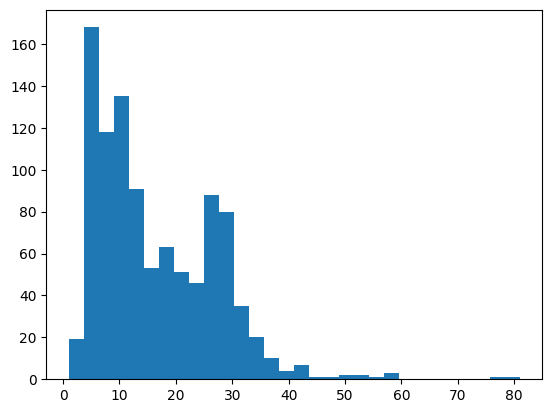

max_length: 30
Best C: 1, CV Accuracy: 87.56%


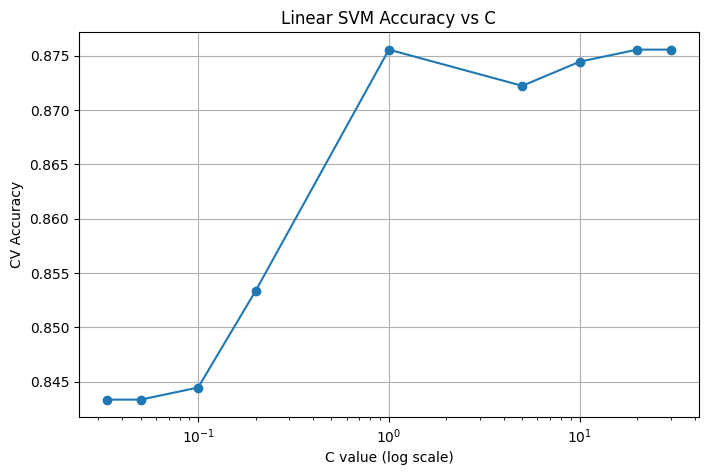

Test Accuracy: 92.00%


In [43]:
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

# 1. 문장 길이 확인 및 padding
x_lengths = [len(seq) for seq in indexing_x_data]
plt.hist(x_lengths, bins=30)
plt.show()
max_length = int(np.percentile(x_lengths, 90))
print("max_length:", max_length)

for index in range(len(indexing_x_data)):
    length = len(indexing_x_data[index])
    if length > max_length:
        indexing_x_data[index] = indexing_x_data[index][:max_length]
    elif length < max_length:
        indexing_x_data[index] += [0]*(max_length-length)

# 2. train/test split
number_of_train = int(len(indexing_x_data)*0.9)
train_x = indexing_x_data[:number_of_train]
train_y = indexing_y_data[:number_of_train]
test_x = indexing_x_data[number_of_train:]
test_y = indexing_y_data[number_of_train:]

# numpy 변환
train_x = np.array(train_x)
test_x = np.array(test_x)
train_y = np.array(train_y)
test_y = np.array(test_y)

# 3. train 데이터 기준 단어 score 계산
index_score = {}
for i in range(len(train_x)):
    seq = train_x[i]
    label = train_y[i]
    for idx in seq:
        if idx == 0: continue
        if idx not in index_score:
            index_score[idx] = 0
        index_score[idx] += 1 if label==1 else -1

# 4. score로 변환
for i in range(len(train_x)):
    seq = train_x[i]
    train_x[i] = [0 if idx==0 else index_score.get(idx,0) for idx in seq]

for i in range(len(test_x)):
    seq = test_x[i]
    test_x[i] = [0 if idx==0 else index_score.get(idx,0) for idx in seq]

# 다시 numpy 변환
train_x = np.array(train_x, dtype=float)
test_x = np.array(test_x, dtype=float)

# 5. 정규화 (안정 버전)
train_x = train_x / (np.max(np.abs(train_x), axis=1, keepdims=True) + 1e-6)
test_x = test_x / (np.max(np.abs(test_x), axis=1, keepdims=True) + 1e-6)

# 6. C 값
C_values = [1/30, 1/20, 1/10, 1/5, 1, 5, 10, 20, 30]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []

for C in C_values:
    fold_accuracies = []

    for train_idx, val_idx in kf.split(train_x):
        X_train_fold = train_x[train_idx]
        X_val_fold = train_x[val_idx]
        y_train_fold = train_y[train_idx]
        y_val_fold = train_y[val_idx]

        # kernel 변경 (poly → linear)
        model = SVC(kernel='linear', C=C)

        model.fit(X_train_fold, y_train_fold)

        preds = model.predict(X_val_fold)
        acc = accuracy_score(y_val_fold, preds)
        fold_accuracies.append(acc)

    accuracies.append(np.mean(fold_accuracies))

best_index = np.argmax(accuracies)
best_C = C_values[best_index]

print(f"Best C: {best_C}, CV Accuracy: {accuracies[best_index]*100:.2f}%")

plt.figure(figsize=(8,5))
plt.plot(C_values, accuracies, marker='o')
plt.xscale('log')
plt.xlabel('C value (log scale)')
plt.ylabel('CV Accuracy')
plt.title('Linear SVM Accuracy vs C')
plt.grid(True)
plt.show()

# 최종 모델
best_svm = SVC(kernel='linear', C=best_C)
best_svm.fit(train_x, train_y)

# 테스트 평가
predict = best_svm.predict(test_x)
accuracy = np.mean(predict == test_y) * 100

print(f"Test Accuracy: {accuracy:.2f}%")

<h2>SVM 모델을 이용한 평가</h2>

<pre>

<b>1. svm.predict(real_test_score) 함수를 사용하여 SVM 모델을 이용한 평가</b>
  
  svm.predict(real_test_score)

  args
    real_test_score : train 데이터 기준으로 생성한 단어 score를 이용해
                      동일한 방식으로 전처리한 실제 테스트 데이터셋
                      ({인덱스 → score} 형태)

  return :
    입력 문장들에 대한 모델의 예측 라벨 리스트

  학습에 사용되지 않은 새로운 데이터(real test set)를
  동일한 전처리 과정을 거쳐 모델에 입력하여 예측을 수행하였다.


<b>2. 성능 측정</b>

  정답 라벨과 모델의 출력 라벨을 비교하여 정확도를 계산하였다.

  실험 결과)
    Accuracy : 약 86%

  train 데이터가 아닌,
  처음 보는 데이터셋에서도 높은 정확도를 유지하는 것을 통해
  모델이 특정 데이터에만 맞춰진 것이 아니라
  일반화된 패턴을 학습했음을 확인할 수 있었다.


<b>3. tokenizer.sequences_to_texts(data)를 이용한 데이터 복원</b>

  tokenizer.sequences_to_texts(data)

  args
    data : 단어 index로 구성된 리스트 (원본 유지 데이터)

  return :
    단어로 변환된 문장 리스트

  모델 입력은 score 기반 데이터이기 때문에
  사람이 결과를 해석하기 어렵다.

  따라서, 별도로 저장해둔 원본 index 데이터를 이용하여
  다시 텍스트로 복원하는 과정을 거쳤다.

  이를 통해 각 문장에 대해
  모델의 예측 결과와 실제 문장을 함께 확인할 수 있도록 하였다.


<b>4. 입력 문장에 대한 모델 출력 비교</b>

  문장 : your free ringtone is waiting to be collected ...
  정답 : spam
  모델 출력 : ham

  문장 : probably money worries things are coming due ...
  정답 : ham
  모델 출력 : ham

  문장 : how is it possible to teach you and where
  정답 : ham
  모델 출력 : spam

  ...

  일부 문장에서 오분류가 발생하였지만,
  전체적으로 spam과 ham을 구분하는 핵심 패턴은
  잘 학습된 것을 확인할 수 있었다.

  특히, 학습에 사용되지 않은 새로운 데이터에서도
  약 86%의 정확도를 유지한다는 점에서

  해당 모델이 단순히 train 데이터에만 맞춰진 것이 아니라,
  실제 환경에서도 적용 가능한 수준의 일반화 성능을 가진다고 볼 수 있다.

</pre>

In [47]:


#위 train_x와 test_x 처럼 동일하게 전처리 진행
real_test_indexed = tokenizer.texts_to_sequences(real_test_x)
real_test_original = real_test_indexed.copy()

real_test_score = []
for seq in real_test_indexed:
    new_seq = [0 if idx==0 else index_score.get(idx,0) for idx in seq]
    real_test_score.append(new_seq)

for i in range(len(real_test_score)):
    length = len(real_test_score[i])
    if length > max_length:
        real_test_score[i] = real_test_score[i][:max_length]
    elif length < max_length:
        real_test_score[i] += [0]*(max_length - length)

for i in range(len(real_test_score)):
    length = len(real_test_score[i])
    if length > max_length:
        real_test_score[i] = real_test_score[i][:max_length]
    elif length < max_length:
        real_test_score[i] += [0]*(max_length - length)


# 최적 모델에 테스트 데이터 넣고 결과 출력
predict = best_svm.predict(real_test_score)
correct_count = 0
for index in range(len(predict)):
  if(test_y[index] == predict[index]):
    correct_count += 1

accuracy = 100.0*correct_count/len(predict)


print("실전 테스트 Accuracy: " + str(accuracy))

#index를 다시 word로 바꾸는 과정
index2label = {0:"spam", 1:"ham"}

# 위와 동일
real_test_word = tokenizer.sequences_to_texts(real_test_original)

for index in range(len(test_x_word)):
  print()
  print("문장 : ", test_x_word[index])
  print("정답 : ", index2label[test_y[index]])
  print("모델 출력 : ", index2label[predict[index]])

실전 테스트 Accuracy: 86.0

문장 :  your free ringtone is waiting to be collected simply text the password mix to 85069 to verify get usher and britney fml po box 5249 mk17 92h 450ppw 16
정답 :  spam
모델 출력 :  ham

문장 :  probably money worries things are coming due and i have several outstanding invoices for work i did two and three months ago
정답 :  ham
모델 출력 :  ham

문장 :  how is it possible to teach you and where
정답 :  ham
모델 출력 :  spam

문장 :  i wonder if your phone battery went dead i had to tell you i love you babe
정답 :  ham
모델 출력 :  ham

문장 :  lovely smell on this bus and it ain't tobacco
정답 :  ham
모델 출력 :  ham

문장 :  we're all getting worried over here derek and taylor have already assumed the worst
정답 :  ham
모델 출력 :  ham

문장 :  hey what's up charles sorry about the late reply
정답 :  ham
모델 출력 :  ham

문장 :  all the lastest from stereophonics marley dizzee racal libertines and the strokes win nookii games with flirt click themob wap bookmark or text wap to 82468
정답 :  spam
모델 출력 :  spam

문장 :